# Tab1 NPZ Reader

?? `tab1_npz_tools.py` ?? Tab1 ??? NPZ ????????????????????????


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from tab1_npz_tools import (
    iter_tab1_npz_files,
    load_tab1_npz,
    plot_time_domain,
    preprocess_waveform,
    save_tab1_npz,
    summarize_tab1_npz,
)


In [6]:
DATA_DIR = Path(r"D:/PCCP/FIPdata")
files = list(iter_tab1_npz_files(DATA_DIR, limit=5))
files


[WindowsPath('D:/PCCP/FIPdata/phase_data_20260320_211109_250_#000149.npz'),
 WindowsPath('D:/PCCP/FIPdata/phase_data_20260320_211139_265_#000299.npz'),
 WindowsPath('D:/PCCP/FIPdata/phase_data_20260320_211245_688_#000387.npz'),
 WindowsPath('D:/PCCP/FIPdata/phase_data_20260320_211326_227_#000149.npz'),
 WindowsPath('D:/PCCP/FIPdata/phase_data_20260320_211356_219_#000299.npz')]

In [13]:
# file_path = files[44]
file_path = Path(r"D:\PCCP\FIPdata1\phase_data_20260320_203723_037_#002199.npz")   
payload = load_tab1_npz(file_path)
summary = summarize_tab1_npz(payload)
summary


{'file_path': 'D:\\PCCP\\FIPdata1\\phase_data_20260320_203743_045_#002299.npz',
 'comm_count': 2299,
 'timestamp': 0.0,
 'sample_rate': 200000.0,
 'length': 2000000,
 'duration_seconds': 10.0,
 'min': 2786.522431458737,
 'max': 2841.4097103954286,
 'mean': 2802.8608909485893,
 'std': 14.041409719537286,
 'data_info': {'type': 'phase_unwrapped_downsampled',
  'length': 2000000,
  'downsample_factor': 5,
  'packet_count': 50,
  'start_comm_count': 2250,
  'end_comm_count': 2299,
  'duration_seconds': 10.0,
  'save_time': '2026-03-20T20:37:43.045121'}}

<Axes: title={'center': 'Tab1 Time-Domain Waveform (200000.0 Hz)'}, xlabel='Time (s)', ylabel='Amplitude'>

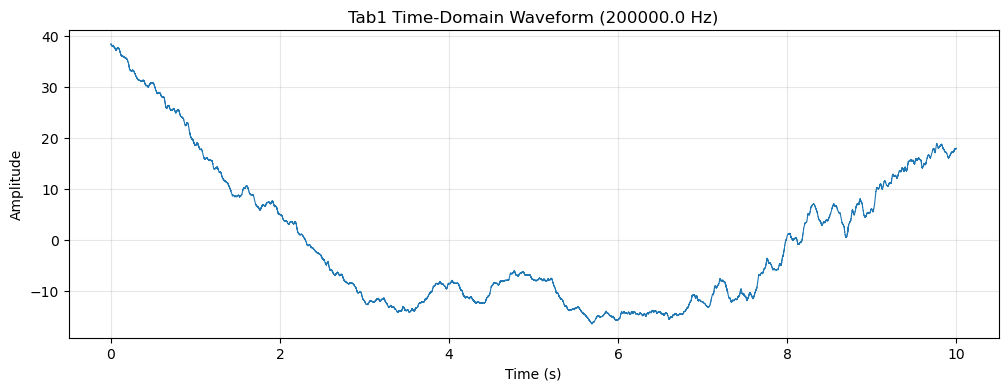

In [14]:
plot_time_domain(
    payload['phase_data'],
    payload['sample_rate'],
    start_time=0.0,
    duration=10,
    downsample_factor=1,
    remove_mean=True,
    normalize=False,
)


In [20]:
times, values, effective_rate = preprocess_waveform(
    payload['phase_data'],
    payload['sample_rate'],
    remove_mean=True,
    normalize=False,
    start_time=0.0,
    duration=0.02,
    downsample_factor=2,
)
effective_rate, values[:10]


(100000.0,
 array([3.17764474, 3.17986482, 3.17736236, 3.18010525, 3.1810947 ,
        3.17848438, 3.1791173 , 3.17863868, 3.18013147, 3.17938545]))

In [13]:
OUTPUT_PATH = NOTEBOOK_DIR / 'output' / 'tab1_preview_processed.npz'
save_tab1_npz(
    OUTPUT_PATH,
    phase_data=values,
    sample_rate=effective_rate,
    comm_count=payload['comm_count'],
    timestamp=payload['timestamp'],
    data_type='offline_preview',
    extra_info={'source_file': str(file_path)},
)
OUTPUT_PATH


WindowsPath('e:/codes/pccpHOST/wb-monitor/read/output/tab1_preview_processed.npz')